# 手写识别算法

## 数据集下载和提取

In [1]:
import os
from skimage import io
import torchvision.datasets.mnist as mnist

root="D:/GitHub/Fanghui-Lang/mechine_learning2024/MNIST/MNIST/raw"
train_set = (
    mnist.read_image_file(os.path.join(root, 'train-images-idx3-ubyte')),
    mnist.read_label_file(os.path.join(root, 'train-labels-idx1-ubyte'))
        )
test_set = (
    mnist.read_image_file(os.path.join(root, 't10k-images-idx3-ubyte')),
    mnist.read_label_file(os.path.join(root, 't10k-labels-idx1-ubyte'))
        )
print("training set :",train_set[0].size())
print("test set :",test_set[0].size())

def convert_to_img(train=True):
    if(train):
        f=open(root+'train.txt','w')
        data_path=root+'/train/'
        if(not os.path.exists(data_path)):
            os.makedirs(data_path)
        for i, (img,label) in enumerate(zip(train_set[0],train_set[1])):
            img_path=data_path+str(i)+'.jpg'
            io.imsave(img_path,img.numpy())
            f.write(img_path+' '+str(label)+'\n')
        f.close()
    else:
        f = open(root + 'test.txt', 'w')
        data_path = root + '/test/'
        if (not os.path.exists(data_path)):
            os.makedirs(data_path)
        for i, (img,label) in enumerate(zip(test_set[0],test_set[1])):
            img_path = data_path+ str(i) + '.jpg'
            io.imsave(img_path, img.numpy())
            f.write(img_path + ' ' + str(label) + '\n')
        f.close()

convert_to_img(True)#转换训练集
convert_to_img(False)#转换测试集

training set : torch.Size([60000, 28, 28])
test set : torch.Size([10000, 28, 28])


## 训练1

Epoch:  0 | Train loss: 0.0813
          | Train acc: 0.9800 
Epoch:  1 | Train loss: 0.0212
          | Train acc: 0.9820 
-------------------------------------------------------------------------
Prediction number [7 2 1 0 4 1 4 9 5 9]
Real number       [7 2 1 0 4 1 4 9 5 9]
-------------------------------------------------------------------------
tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3])


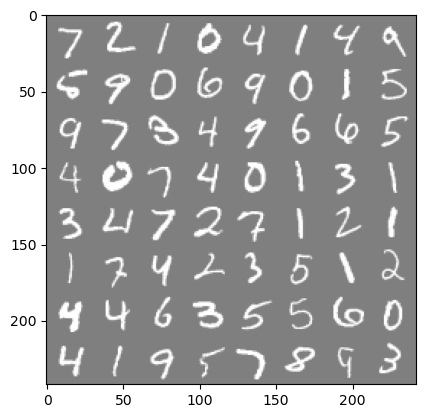

In [3]:
import torch
import torch.nn as nn
import torchvision 
import torch.utils.data as Data
import matplotlib.pyplot as plt
 
torch.manual_seed(1)  # 设置随机种子, 用于复现
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
 
# 超参数
EPOCH = 2       # 前向后向传播迭代次数
LR = 0.001      # 学习率 learning rate 
BATCH_SIZE = 64 # 批量训练时候一次送入数据的size，一般设置为2的幂次方，batch_size大则epoch也要大
DOWNLOAD_MNIST = True 
 
# 下载mnist手写数据集
# 训练集
train_data = torchvision.datasets.MNIST(  
    root = './MNIST/',                      
    train = True,                            
    transform = torchvision.transforms.ToTensor(),                                                
    download=DOWNLOAD_MNIST 
)
 
# 测试集
test_data = torchvision.datasets.MNIST(
    root = './MNIST/', 
    train = False,
    transform=torchvision.transforms.ToTensor()
)  # train设置为False表示获取测试集
 
# 加载数据集
# 一个批训练 50个样本, 1 channel通道, 图片尺寸 28x28 size:(50, 1, 28, 28)
train_loader = Data.DataLoader(
    dataset = train_data,
    batch_size = BATCH_SIZE,
    shuffle = True
) 
test_loader = Data.DataLoader(
    dataset = test_data,
    batch_size = BATCH_SIZE,
    shuffle = False
) 


#  测试数据预处理；只测试前2000个
# test_x代表图片，test_y代表标签
test_x = torch.unsqueeze(test_data.data,dim=1).float()[:2000] / 255.0
test_x = test_x.to(device)
# shape from (2000, 28, 28) to (2000, 1, 28, 28)
test_y = test_data.targets[:2000]
test_y = test_y.to(device)
 
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
 
        self.conv1 = nn.Sequential(
            nn.Conv2d(                      # 输入的图片 （1，28，28）
                in_channels=1,
                out_channels=16,            # 经过一个卷积层之后 （16,28,28）
                kernel_size=5,
                stride=1,                    # 如果想要 con2d 出来的图片长宽没有变化, padding=(kernel_size-1)/2 当 stride=1
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)      # 经过池化层处理，维度为（16,14,14）
        )
 
        self.conv2 = nn.Sequential(
            nn.Conv2d(                         # 输入（16,14,14）
                in_channels=16,
                out_channels=32,
                kernel_size=5,
                stride=1,
                padding=2
            ),                                 # 输出（32,14,14）
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)        # 输出（32,7,7）
        )
 
        self.out = nn.Linear(32*7*7,10)
 
    def forward(self, x):
        x = self.conv1(x)                     #（batch_size,16,14,14）
        x = self.conv2(x)                     # 输出（batch_size,32,7,7）
        x = x.view(x.size(0),-1)              # (batch_size,32*7*7)
        out = self.out(x)                     # (batch_size,10)
        return out
# 使用GPU进行训练，如果GPU可获得则用cuda训练，否则CPU
# 如果不进行GPU加速则去掉to(device)
cnn = CNN().to(device)
optimizer = torch.optim.Adam(cnn.parameters(),lr=LR) # 定义优化器
loss_func = nn.CrossEntropyLoss() # 定义损失函数

for epoch in range(EPOCH):
    # step表示第几个批次的数据，一个批次里有batch_size组数据，batch_x代表训练集，batch_y表示训练集的标签，
    for step,(batch_x,batch_y) in enumerate(train_loader):
        # 将input的tensor转换成了CUDA 类型
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # pred_y是识别结果，这里是对训练集的识别
        pred_y = cnn(batch_x)
        loss = loss_func(pred_y,batch_y)
        optimizer.zero_grad() # 清空上一层梯度
        loss.backward() # 反向传播
        optimizer.step() # 更新优化器的学习率，一般按照epoch为单位进行更新
    
    # 输出每一代的准确度
    pred_output = cnn(test_x)
    pred = torch.max(pred_output, 1)[1].cpu()
    print('Epoch: ', epoch, '| Train loss: %.4f' % loss.data.cpu().numpy())
    # print(torch.eq(y_predict,y_truth.squeeze(dim=-1)).float())
    # tensor([1., 0., 1., 1., 0., 1., 1., 1., 1., 1.])

    print("          | Train acc: %.4f " % (torch.eq(pred,test_y.cpu())).float().mean())

print('-------------------------------------------------------------------------')

# 打印前十个测试结果和真实结果进行对比
test_output = cnn(test_x[:10])
pred_y = torch.max(test_output, 1)[1].cpu().numpy()
print('Prediction number',pred_y)
print('Real number      ',test_y[:10].cpu().numpy())

print('-------------------------------------------------------------------------')
# 实现可视化
images, labels = next(iter(test_loader))
img = torchvision.utils.make_grid(images)

img = img.numpy().transpose(1, 2, 0)
std = [0.5, 0.5, 0.5]
mean = [0.5, 0.5, 0.5]
img = img * std + mean
print(labels)
plt.imshow(img)
plt.show()